# AR(p) Parameter Estimation

The $\text{AR}(p)$ process is defined by,

$
\begin{align}
X_t = \sum_{i=1}^p \varphi_i X_{t-i} + \varepsilon_{t}
\end{align}
\tag{1}
$

where,

$
\begin{align}
\varepsilon_t \sim \text{Normal}(0, \sigma^2)
\end{align}
\tag{2}
$

The Yule-Walker equations are relate the AR(p) parameters $\varphi_i$ to the autocorrelation function. If zero mean is</br>
assumed it follows that,

$
\begin{align}
\rho_n = \frac{\text{E}[X_t X_{t-n}]}{\text{E}[X_t^2]}
\end{align}
\tag{3}
$

The autocorrelation functions can be shown to have the following properties,

$
\begin{align}
&\rho_0 = 1 \\
&\rho_n \leq 1 \\
&\rho_n = \rho_{-n}
\end{align}
\tag{4}
$

Define the matrices,

$
\begin{align}
\hat{r} =
\begin{bmatrix}
\rho_1 \\
\rho_2 \\
\rho_3 \\
\vdots \\
\rho_{n-1} \\
\rho_{n}
\end{bmatrix}
\end{align}
\tag{5}
$

$
\begin{align}
\hat{\Phi} =
\begin{bmatrix}
\varphi_1 \\
\varphi_2 \\
\varphi_3 \\
\vdots \\
\varphi_{n-1} \\
\varphi_{n}
\end{bmatrix}
\end{align}
\tag{6}
$

$
\begin{align}
\hat{R} =
\begin{bmatrix}
1 & \rho_1 & \rho_2 & \cdots & \rho_{n-2} & \rho_{n-1} \\
\rho_1 & 1 & \rho_1 & \cdots & \rho_{n-3} & \rho_{n-2} \\
\rho_2 & \rho_1 & 1 & \cdots & \rho_{n-4} & \rho_{n-3} \\
\vdots & \vdots  & \vdots & \ddots & \vdots & \vdots \\
\rho_{n-2} & \rho_{n-3} & \rho_{n-4} & \cdots & 1 & \rho_1 \\
\rho_{n-1} & \rho_{n-2} & \rho_{n-3} & \cdots & \rho_1 & 1 \\
\end{bmatrix}
\end{align}
\tag{7}
$

Then the Yule-Walker equations are given by,

$
\begin{align}
\hat{\Phi} = \hat{R}^{-1} \hat{r}
\end{align}
\tag{8}
$

## Examples

The Yule-Walker equations for $\text{AR}(1)$ is given by,

$
\begin{align}
\varphi_1 = \rho_1
\end{align}
\tag{9}
$

This is the OLS solution.

For $\text{AR}(2)$,

$
\begin{align}
\varphi_1 &= \frac{\rho_1 - \rho_1 \rho_2}{1 - \rho_1^2} \\
\varphi_2 &= \frac{\rho_2 - \rho_1^2}{1 - \rho_1^2}
\end{align}
\tag{10}
$

## Stationaity

Stationarity of an $\text{AR}(p)$ leads to convergence of the moments as $t \to \infty$. Recall the shift operator, $L$, defined by,

$
\begin{align}
&L X_t = X_{t-1} \\
&L^2 X_t = X_{t-2} \\
&L^3 X_t = X_{t-3} \\
&\vdots
\end{align}
\tag{11}
$

An $\text{AR}(p)$ process can be written as,

$
\begin{align}
\varepsilon_t = (1 - \varphi L - \varphi^2 L^2 - \varphi^3 L^3 - \cdots - \varphi^p L^p) X_t
\end{align}
\tag{12}
$

The characteristic equation is obtained by replacing $L$ with the variable $z$ and setting the result to zero,

$
\begin{align}
1 - \varphi z - \varphi^2 z^2 - \varphi^3 z^3 - \cdots - \varphi^p z^p = 0
\end{align}
\tag{13}
$

Stationarity requires that $\lvert z \rvert > 1$. To see this consider $\text{AR}(1)$. The characteristic equation is,

$
\begin{align}
1 - \varphi z = 0
\end{align}
\tag{14}
$

The solution is $z = \frac{1}{\varphi}$. It follows that stationarity requires,

$
\begin{align}
\lvert \varphi \rvert < 1
\end{align}
\tag{15}
$

## Imports

In [23]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import arima
from lib.plots import stack, fpoints, fcurve
from lib.utils import create_parameter_scan

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [24]:
nsample = 1000

def comparison_plot(φ_vals, title, ylim, *params):
    labels = [f"φ={val}" for val in φ_vals] 
    ylabels = r"$S_t$"
    source = lambda **kwargs : arima.create_ar_source(**kwargs)
    t, scan = create_parameter_scan(source, *params)
    stack(scan, t, ylim=ylim, title=title, labels=labels, ylabels=ylabels, xlabel="Time", figsize=(10, 6), lw=1)
    return t, scan

## Simulations

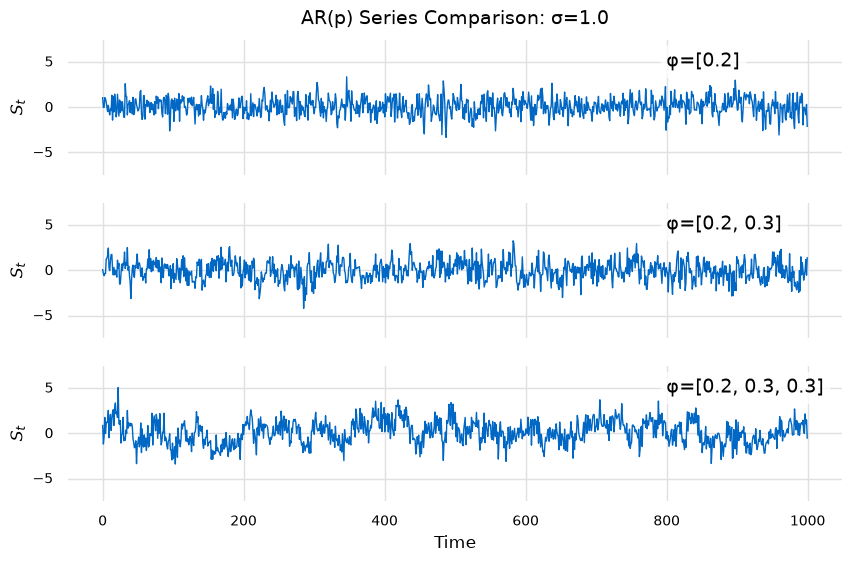

In [25]:
σ = 1.0
title = f"AR(p) Series Comparison: σ={σ}"
φ_vals = [[0.2], [0.2, 0.3], [0.2, 0.3, 0.3]]
params = [{"φ": φ, "σ": σ, "npts": nsample} for φ in φ_vals]
_, ar = comparison_plot(φ_vals, title, [-7.5, 7.5], *params)

## Estimation of $\text{AR}(p)$ Parameters ($\sigma = 1$)

$\text{AR}(p)$ parameters are estimated using two methods. The Yule-Walker ACF and `statsmodels.tsa.arima_model.ARMA`

### AR(1) Example $\varphi = 0.2$

In [26]:
arima.compute_pacf(ar[0], nlags=1)

(array([1.]), array([0.1781421]))

In [27]:
result, result_model = arima.compute_ar_estimate(ar[0], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1377.720
Date:                Sun, 23 Aug 2026   AIC                           2761.440
Time:                        14:19:05   BIC                           2776.164
Sample:                             0   HQIC                          2767.036
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0840      0.037      2.267      0.023       0.011       0.157
ar.L1          0.1790      0.030      5.950      0.000       0.120       0.238
sigma2         0.9209      0.039     23.358      0.000       0.844       0.998
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 3.04
Prob(Q):                              1.00   Prob(JB):                         0.22
Heteroskedasticity (H):               1.07   Skew:                            -0.09
Prob(H) (two-sided):                  0.54   Kurtosis:                         3.20
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [28]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR",
   "const": {
      "est": 0.08398391051361896,
      "err": 0.037048895319833075,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "82fcce75-6f87-4e7c-bd42-edf6498c972f",
      "param_type": "ARMA_CONST"
   },
   "order": 1,
   "params": [
      {
         "est": 0.17904698401066266,
         "err": 0.030094291964808454,
         "est_label": "$\\hat{\\phi_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\\phi_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "82fcce75-6f87-4e7c-bd42-edf6498c972f",
         "param_type": "ARMA_PARAM"
      }
   ],
   "sigma2": {
      "est": 0.9209042705376124,
      "err": 0.039425136870802846,
      "est_label": "$\\hat{\\sigma^2}$",
      "err_label": "$\\sigma_{\\hat{\\sigma^2}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "82f

### AR(2) Example $\varphi = [0.2, 0.3]$

In [29]:
arima.compute_pacf(ar[1], nlags=2)

(array([1., 2.]), array([0.19900809, 0.2770301 ]))

In [30]:
result, result_model = arima.compute_ar_estimate(ar[1], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1431.547
Date:                Sun, 23 Aug 2026   AIC                           2871.093
Time:                        14:19:05   BIC                           2890.724
Sample:                             0   HQIC                          2878.554
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0480      0.061     -0.786      0.432      -0.168       0.072
ar.L1          0.1989      0.030      6.541      0.000       0.139       0.258
ar.L2          0.2769      0.030      9.380      0.000       0.219       0.335
sigma2         1.0253      0.047     21.947      0.000       0.934       1.117
===================================================================================
Ljung-Box (L1) (Q):                   0.24   Jarque-Bera (JB):                 0.22
Prob(Q):                              0.62   Prob(JB):                         0.90
Heteroskedasticity (H):               1.08   Skew:                             0.01
Prob(H) (two-sided):                  0.50   Kurtosis:                         2.93
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [31]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR",
   "const": {
      "est": -0.04802207861644842,
      "err": 0.06109634108098813,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "7cf4eb65-c360-40dd-96f9-dfa30ed1a193",
      "param_type": "ARMA_CONST"
   },
   "order": 2,
   "params": [
      {
         "est": 0.19886536137563088,
         "err": 0.030401251164036816,
         "est_label": "$\\hat{\\phi_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\\phi_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "7cf4eb65-c360-40dd-96f9-dfa30ed1a193",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.27688075039268967,
         "err": 0.029519080570612442,
         "est_label": "$\\hat{\\phi_{1}}$",
         "err_label": "$\\sigma_{$\\hat{\\phi_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 2,
         

### AR(3) Example $\varphi = [0.2, 0.3, 0.3]$

In [32]:
arima.compute_pacf(ar[2], nlags=3)

(array([1., 2., 3.]), array([0.24659661, 0.27016908, 0.25234848]))

In [33]:
result, result_model = arima.compute_ar_estimate(ar[2], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(3, 0, 0)   Log Likelihood               -1427.035
Date:                Sun, 23 Aug 2026   AIC                           2864.070
Time:                        14:19:05   BIC                           2888.609
Sample:                             0   HQIC                          2873.396
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1311      0.137      0.956      0.339      -0.138       0.400
ar.L1          0.2452      0.032      7.699      0.000       0.183       0.308
ar.L2          0.2701      0.031      8.778      0.000       0.210       0.330
ar.L3          0.2526      0.031      8.263      0.000       0.193       0.313
sigma2         1.0155      0.046     22.063      0.000       0.925       1.106
===================================================================================
Ljung-Box (L1) (Q):                   0.16   Jarque-Bera (JB):                 0.94
Prob(Q):                              0.69   Prob(JB):                         0.63
Heteroskedasticity (H):               0.99   Skew:                             0.07
Prob(H) (two-sided):                  0.90   Kurtosis:                         2.98
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [34]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR",
   "const": {
      "est": 0.13107028194971315,
      "err": 0.13709153996575943,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "61465d8f-f825-4c3b-8ad4-3ebe17e49faf",
      "param_type": "ARMA_CONST"
   },
   "order": 3,
   "params": [
      {
         "est": 0.2452356946658904,
         "err": 0.031852290769307005,
         "est_label": "$\\hat{\\phi_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\\phi_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "61465d8f-f825-4c3b-8ad4-3ebe17e49faf",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.2701382649203068,
         "err": 0.030775131887571555,
         "est_label": "$\\hat{\\phi_{1}}$",
         "err_label": "$\\sigma_{$\\hat{\\phi_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 2,
         "es

## Simulations $\sigma = 5.0$

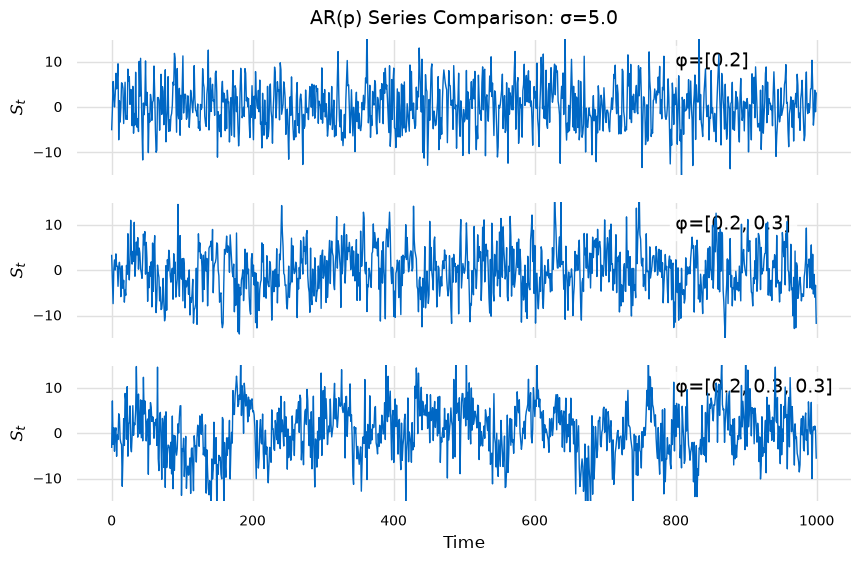

In [35]:
σ = 5.0
title = f"AR(p) Series Comparison: σ={σ}"
φ_vals = [[0.2], [0.2, 0.3], [0.2, 0.3, 0.3]]
params = [{"φ": φ, "σ": σ, "npts": nsample} for φ in φ_vals]
_, ar = comparison_plot(φ_vals, title, [-15.0, 15.0], *params)

### AR(1) Example ($\varphi = 0.2$)

In [36]:
arima.compute_pacf(ar[0], nlags=1)

(array([1.]), array([0.18654875]))

In [37]:
result, result_model = arima.compute_ar_estimate(ar[0], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -3020.226
Date:                Sun, 23 Aug 2026   AIC                           6046.452
Time:                        14:19:05   BIC                           6061.175
Sample:                             0   HQIC                          6052.048
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2922      0.193      1.513      0.130      -0.086       0.671
ar.L1          0.1867      0.033      5.667      0.000       0.122       0.251
sigma2        24.5933      1.120     21.965      0.000      22.399      26.788
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                 0.17
Prob(Q):                              0.90   Prob(JB):                         0.92
Heteroskedasticity (H):               1.06   Skew:                            -0.01
Prob(H) (two-sided):                  0.57   Kurtosis:                         2.94
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [38]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR",
   "const": {
      "est": 0.2921933182602206,
      "err": 0.1931286241671181,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "92f41c9b-cdfc-4fe2-b9cd-676ba499f006",
      "param_type": "ARMA_CONST"
   },
   "order": 1,
   "params": [
      {
         "est": 0.18665710880676092,
         "err": 0.03293505897966335,
         "est_label": "$\\hat{\\phi_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\\phi_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "92f41c9b-cdfc-4fe2-b9cd-676ba499f006",
         "param_type": "ARMA_PARAM"
      }
   ],
   "sigma2": {
      "est": 24.59329845073835,
      "err": 1.1196424367885303,
      "est_label": "$\\hat{\\sigma^2}$",
      "err_label": "$\\sigma_{\\hat{\\sigma^2}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "92f41c9b-c

### AR(2) Example ($\varphi = [0.2, 0.3]$)

In [39]:
arima.compute_pacf(ar[1], nlags=2)

(array([1., 2.]), array([0.20687938, 0.23754606]))

In [40]:
result, result_model = arima.compute_ar_estimate(ar[1], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -3031.968
Date:                Sun, 23 Aug 2026   AIC                           6071.936
Time:                        14:19:05   BIC                           6091.567
Sample:                             0   HQIC                          6079.397
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0834      0.288     -0.290      0.772      -0.647       0.480
ar.L1          0.2076      0.033      6.381      0.000       0.144       0.271
ar.L2          0.2384      0.032      7.565      0.000       0.177       0.300
sigma2        25.1754      1.131     22.258      0.000      22.958      27.392
===================================================================================
Ljung-Box (L1) (Q):                   0.07   Jarque-Bera (JB):                 2.48
Prob(Q):                              0.80   Prob(JB):                         0.29
Heteroskedasticity (H):               1.02   Skew:                             0.12
Prob(H) (two-sided):                  0.82   Kurtosis:                         3.00
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [41]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR",
   "const": {
      "est": -0.08335121290708614,
      "err": 0.2876251108419103,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "d260a133-68fe-4d0b-867b-cd86302c5591",
      "param_type": "ARMA_CONST"
   },
   "order": 2,
   "params": [
      {
         "est": 0.20763500890649367,
         "err": 0.032540857273670926,
         "est_label": "$\\hat{\\phi_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\\phi_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "d260a133-68fe-4d0b-867b-cd86302c5591",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.23837140722630257,
         "err": 0.03151159407096807,
         "est_label": "$\\hat{\\phi_{1}}$",
         "err_label": "$\\sigma_{$\\hat{\\phi_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 2,
         "e

### AR(3) Example ($\varphi = [0.2, 0.3, 0.3]$)

In [42]:
arima.compute_pacf(ar[2], nlags=3)

(array([1., 2., 3.]), array([0.14026559, 0.2512005 , 0.31332719]))

In [43]:
result, result_model = arima.compute_ar_estimate(ar[1], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(3, 0, 0)   Log Likelihood               -3031.356
Date:                Sun, 23 Aug 2026   AIC                           6072.711
Time:                        14:19:05   BIC                           6097.250
Sample:                             0   HQIC                          6082.038
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0852      0.298     -0.286      0.775      -0.669       0.499
ar.L1          0.1993      0.033      5.997      0.000       0.134       0.264
ar.L2          0.2311      0.032      7.286      0.000       0.169       0.293
ar.L3          0.0351      0.032      1.113      0.266      -0.027       0.097
sigma2        25.1449      1.130     22.251      0.000      22.930      27.360
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 2.44
Prob(Q):                              1.00   Prob(JB):                         0.29
Heteroskedasticity (H):               1.03   Skew:                             0.12
Prob(H) (two-sided):                  0.81   Kurtosis:                         3.00
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [44]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR",
   "const": {
      "est": -0.0852287905053889,
      "err": 0.29789984815513926,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "086b33ec-62c8-4699-8cc7-43f7c726b22d",
      "param_type": "ARMA_CONST"
   },
   "order": 3,
   "params": [
      {
         "est": 0.19928944115405306,
         "err": 0.03323045124411037,
         "est_label": "$\\hat{\\phi_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\\phi_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "086b33ec-62c8-4699-8cc7-43f7c726b22d",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.2311236584342496,
         "err": 0.031721265845380306,
         "est_label": "$\\hat{\\phi_{1}}$",
         "err_label": "$\\sigma_{$\\hat{\\phi_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 2,
         "es